In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [6]:
# Load datasets
X_train = pd.read_csv(
    r"D:\imu-har-exoskeleton-ai\data\UCI HAR Dataset\UCI HAR Dataset\train\X_train.txt",
    sep=r"\s+",
    header=None
)

y_train = pd.read_csv(
    r"D:\imu-har-exoskeleton-ai\data\UCI HAR Dataset\UCI HAR Dataset\train\y_train.txt",
    header=None
)

X_test = pd.read_csv(
    r"D:\imu-har-exoskeleton-ai\data\UCI HAR Dataset\UCI HAR Dataset\test\X_test.txt",
    sep=r"\s+",
    header=None
)

y_test = pd.read_csv(
    r"D:\imu-har-exoskeleton-ai\data\UCI HAR Dataset\UCI HAR Dataset\test\y_test.txt",
    header=None
)

In [7]:
# Load feature names
features = pd.read_csv(
    r"D:\imu-har-exoskeleton-ai\data\UCI HAR Dataset\UCI HAR Dataset\features.txt",
    sep=r"\s+",
    header=None,
    names=["Index", "Feature"]
)

X_train.columns = features["Feature"]
X_test.columns = features["Feature"]

In [8]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train[0])

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_train)

In [10]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

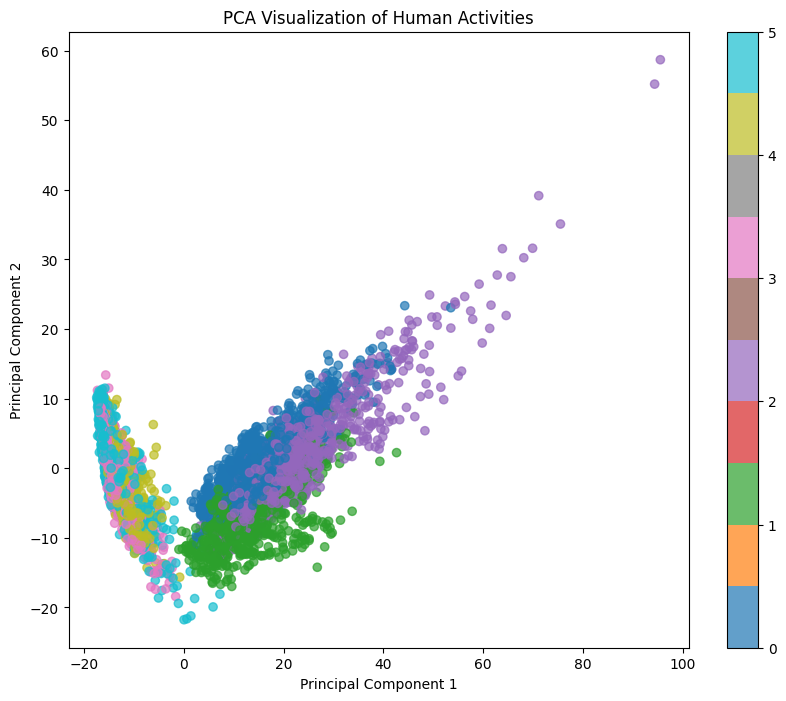

In [23]:
plt.figure(figsize=(10,8))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_train_encoded,
    cmap='tab10',
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Visualization of Human Activities")

plt.colorbar(scatter)


plt.savefig(
    "D:/imu-har-exoskeleton-ai/results/pca_visualization.png",
    dpi=300,
    bbox_inches="tight"
)




In [12]:
print(pca.explained_variance_ratio_)

[0.50781172 0.0658068 ]


In [13]:
print(
    "Total variance preserved:",
    np.sum(pca.explained_variance_ratio_)
)

Total variance preserved: 0.5736185255809917


In [14]:
from sklearn.manifold import TSNE

In [15]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X_scaled)

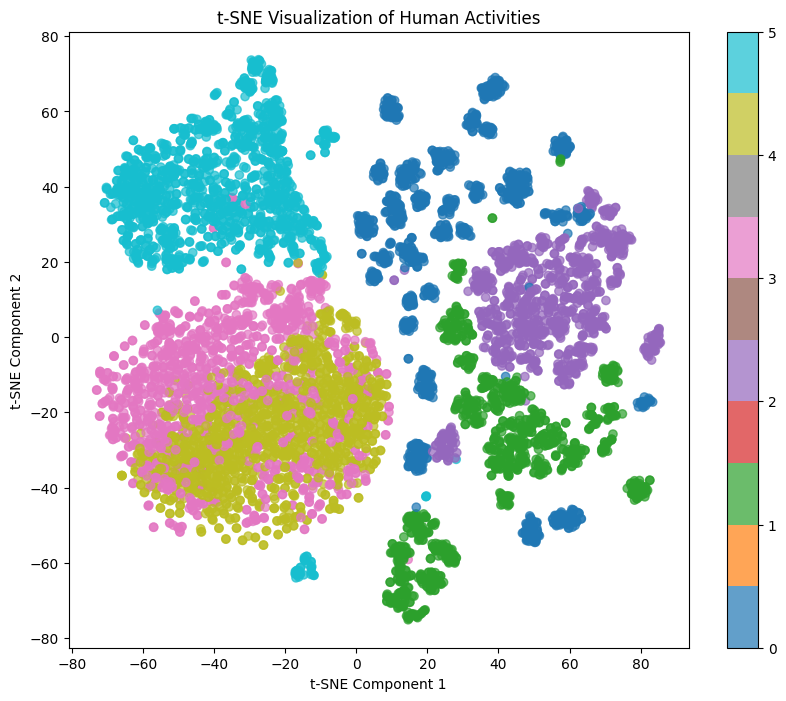

In [24]:
plt.figure(figsize=(10,8))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_train_encoded,
    cmap="tab10",
    alpha=0.7
)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

plt.title("t-SNE Visualization of Human Activities")

plt.colorbar(scatter)


plt.savefig(
    "D:/imu-har-exoskeleton-ai/results/tsne_visualization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()